<a href="https://colab.research.google.com/github/ja4275/jemima_INFO4670_Fall2026/blob/main/Copy_of_Week5_INFO4670_Assignment2_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INFO 4670 / 4760 — Assignment 2 (Framework)
### Cleaning & Integrating the Northgate Data

Fill in each **# TODO** cell with your code, then run the **✅ Check** cell under it to see if it passes. Work top to bottom. When you're done, run the whole notebook once (Runtime → Run all), make sure it runs cleanly, and submit your **GitHub link**.

- Do every fix on a **copy** — never overwrite the raw files.
- The Week 5 Guided notebook shows every technique you need.
- You're graded on correct operations **and** justified decisions (see the rubric).

## Setup — load the three files (given)

In [43]:
import pandas as pd, numpy as np, os
try:
    students = pd.read_csv("student_records.csv")
except FileNotFoundError:
    from google.colab import files
    print("Upload student_records.csv, course_enrollments.csv, weekly_activity.csv")
    files.upload()
    students = pd.read_csv("student_records.csv")
enroll   = pd.read_csv("course_enrollments.csv")
activity = pd.read_csv("weekly_activity.csv")
# Golden rule: work on copies, never overwrite the raw files.
print("students", students.shape, "| enroll", enroll.shape, "| activity", activity.shape)

students (2027, 12) | enroll (8088, 4) | activity (32000, 4)


## Part A · Clean student_records

### A1 · Missing values
Find how many values are missing in `study_hours_reported` and store the count as **`n_missing_study`**. Then, in the markdown cell after your code, say in 1–2 sentences which of Han's methods you would use to handle it and why.
*Hint:* `.isna().sum()`

In [44]:
# TODO: set n_missing_study to the number of blank study_hours_reported values
n_missing_study = students['study_hours_reported'].isna().sum()

**Your justification (1–2 sentences):** I would use Han's ignore method and leave the blanks be as there is a good chance they are missing not at random. I would flag and report how many did not response so the mean would be honest.

In [45]:
# ✅ Check
try:
    assert n_missing_study == 255
    print("✅ A1 correct — 255 missing (n = 1772 present)")
except Exception:
    print("❌ A1 not yet — set n_missing_study to the count of blank study_hours_reported")

✅ A1 correct — 255 missing (n = 1772 present)


### A2 · Inconsistent categories
Standardize the `housing` column into its three real groups and store the result as a new column **`students["housing_clean"]`**.
*Hint:* `.str.strip().str.lower().map({...})`

In [46]:
# TODO: create students["housing_clean"] with exactly 3 standardized groups
clean_map = {"on-campus":"On-Campus", "off-campus":"Off-Campus",
             "off campus":"Off-Campus", "with family":"With Family"}
students["housing_clean"] = students["housing"].str.strip().str.lower().map(clean_map)
print(students["housing_clean"].value_counts())

housing_clean
Off-Campus     945
On-Campus      590
With Family    492
Name: count, dtype: int64


In [47]:
# ✅ Check
try:
    assert students["housing_clean"].nunique() == 3
    print("✅ A2 correct — 3 groups:", {k:int(v) for k,v in students["housing_clean"].value_counts().items()})
except Exception:
    print("❌ A2 not yet — housing_clean should have exactly 3 groups (expect 590 / 945 / 492)")

✅ A2 correct — 3 groups: {'Off-Campus': 945, 'On-Campus': 590, 'With Family': 492}


### A3 · Errors vs. extremes
Find the impossible values. Store the sorted unique impossible ages as **`impossible_ages`** and the number of rows with negative work hours as **`n_neg_work`**. (Remember: extreme-but-valid values like a long commute are *kept*.)
*Hint:* boolean masks on `age` and `work_hours_per_week`.

In [48]:
# TODO
impossible_ages = sorted(int(a) for a in students.loc[(students["age"] < 15) | (students["age"] > 90), "age"].unique())
n_neg_work = (students["work_hours_per_week"] < 0).sum()

In [49]:
# ✅ Check
try:
    assert 220 in impossible_ages and -22 in impossible_ages and n_neg_work == 4
    print("✅ A3 correct — impossible ages incl. -22/199/220; 4 negative work-hour rows")
except Exception:
    print("❌ A3 not yet — check ages (e.g. -22, 199, 220) and count negative work hours (expect 4)")

✅ A3 correct — impossible ages incl. -22/199/220; 4 negative work-hour rows


### A4 · Duplicates
Remove duplicate **student** records and store the result as **`students_dedup`**. Then, in the markdown cell after your code, explain in one sentence why you must NOT de-duplicate `enroll` or `activity` by ID.
*Hint:* `.drop_duplicates()` — think about exact vs. near-duplicates.

In [50]:
# TODO: build students_dedup (one row per student)
students_dedup = students.drop_duplicates()
students_dedup = students.drop_duplicates(subset = "student_id")

**Why not de-dupe enroll / activity? (1 sentence):** Both enrollment and activity have duplicate IDs by design.

In [51]:
# ✅ Check
try:
    assert len(students_dedup) == 2000 and students_dedup["student_id"].is_unique
    print("✅ A4 correct — 2000 unique students (from 2027 rows)")
except Exception:
    print("❌ A4 not yet — students_dedup should be 2000 rows, one per student")

✅ A4 correct — 2000 unique students (from 2027 rows)


## Part B · Integrate the three files

### B5 · Standardize the key & integrate
Build one **row-per-student** analysis table called **`analysis`**: start from `students_dedup`, add a standardized numeric key, and merge in a per-student summary of `activity` (e.g., total `minutes_active`).
*Hint:* make the key with `.str.replace("NU-","")` → `int`; summarize activity with `groupby(...).sum()`; then `merge`.

In [52]:
# TODO: build the standardized key and the one-row-per-student "analysis" table
key= students_dedup["student_id"].str.replace("NU-", "", regex=False).astype(int)

activity_sum = activity.groupby("student_id").sum()

analysis = students_dedup.merge(activity_sum, on = "student_id", how ="left")

In [53]:
# ✅ Check
try:
    assert len(analysis) == 2000 and analysis["student_id"].is_unique
    print("✅ B5 correct — one row per student, 2000 rows")
except Exception:
    print("❌ B5 not yet — analysis should have one row per student (2000)")

✅ B5 correct — one row per student, 2000 rows


### B6 · Verify the join
Report how many `enroll` rows match a student in your standardized key. Store the count as **`matched`**.
*Hint:* `enroll["sid"].isin(set_of_keys).sum()`

In [54]:
# TODO
matched = enroll["sid"].isin(set(key)).sum()

In [55]:
# ✅ Check
try:
    assert matched == 8041
    print("✅ B6 correct — 8041 of 8088 enrollment rows match (14 orphan IDs)")
except Exception:
    print("❌ B6 not yet — count enrollment rows whose sid is in your student keys (expect 8041)")

✅ B6 correct — 8041 of 8088 enrollment rows match (14 orphan IDs)


## Part C · Transform

### C7 · Parse the dates
Parse `enrollment_date` so no valid date is lost. Store the parsed series as **`dates_parsed`** and check the number of NaT (blanks).
*Hint:* `pd.to_datetime(..., format="mixed", errors="coerce")` — compare NaT before and after.

In [56]:
# TODO
dates_parsed = pd.to_datetime(analysis["enrollment_date"], format="mixed", errors="coerce")

In [57]:
# ✅ Check
try:
    assert dates_parsed.isna().sum() == 0
    print("✅ C7 correct — all dates parsed, 0 lost (a naive parse would lose ~1470)")
except Exception:
    print("❌ C7 not yet — parse every format so no valid date becomes NaT")

✅ C7 correct — all dates parsed, 0 lost (a naive parse would lose ~1470)


### C8 · Normalize & discretize
Add two columns to `analysis`: a **z-scored** numeric column stored as **`analysis["study_z"]`**, and a **GPA band** column stored as **`analysis["gpa_band"]`** (bin `final_gpa` into 4 bands).
*Hint:* z-score = `(x - x.mean()) / x.std()`; bands = `pd.cut(..., bins=[-0.01,1,2,3,4])`.

In [58]:
# TODO: add analysis["study_z"] and analysis["gpa_band"]
analysis ["study_z"] =  (analysis["study_hours_reported"] - analysis["study_hours_reported"].mean())/analysis["study_hours_reported"].std()

analysis["gpa_band"] = pd.cut(analysis["final_gpa"], bins = [-0.01,1,2,3,4], labels = ["0-1","1-2"," 2-3", "3-4"])

In [59]:
# ✅ Check
try:
    assert analysis["gpa_band"].nunique() == 4 and abs(analysis["study_z"].mean()) < 0.01
    print("✅ C8 correct — z-score (mean ≈ 0) and 4 GPA bands added")
except Exception:
    print("❌ C8 not yet — add a z-scored column and a 4-band gpa_band column")

✅ C8 correct — z-score (mean ≈ 0) and 4 GPA bands added


## Part D · Deliver & reflect

### D9 · Write the clean file
Write your clean `analysis` table to **`northgate_clean.csv`** (do NOT overwrite the raw files).
*Hint:* `.to_csv("northgate_clean.csv", index=False)`

In [60]:
# TODO: write analysis to northgate_clean.csv
analysis.to_csv("northgate_clean.csv", index = False)

In [61]:
# ✅ Check
try:
    assert os.path.exists("northgate_clean.csv")
    print("✅ D9 correct — northgate_clean.csv written (raw files untouched)")
except Exception:
    print("❌ D9 not yet — write analysis to northgate_clean.csv")

✅ D9 correct — northgate_clean.csv written (raw files untouched)


### D10 · Cleaning log
In the markdown cell below, list each decision you made above and a one-line justification for it (missing values, housing, impossible values, duplicates, key, dates). *This is graded — no code needed.*

**Your cleaning log:**
- I decided to leave the missing values as it is and just to note it when reporting the average, as the blanks might be missing not at random and filling it will pull the mean in the wrong direction.
- I standardized housing into 3 categories so everything is counted correctly and the real groups are shown.
- Ages that are negative, or inhumanly high, and negative work hours are impossible values and not extreme but valid values that need to be kept; they are all impossible in real life so these are errors that need to be removed.
* Both enrollment and activity have duplicate IDs by design in their table grain, students records aren't supposed to have repeated IDs so those are a duplicate that need to be removed as to prevent double-counts.  
*  I standardized the key so the files can join and a one row per student table called analysis can be created by joining student_records with course_enrollments and a per-student summary of weekly_activity.
*   The dates needed parsing into a real date type so the computer can recognize them.






### D11 · Payoff
Using your clean `analysis` table, report the **mean GPA** and **one relationship** you find interesting, then note in one sentence how cleaning changed the picture versus the raw data.

mean GPA = 2.31


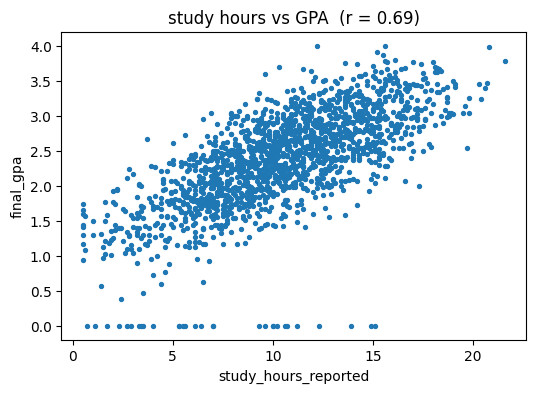

Takeaway: The cleaning had little effect on the overall GPA vs Study hours picture, except a slight decrease in r, as mean remained the same after cleaning.


In [62]:
# TODO: compute the mean GPA and explore one relationship on the CLEAN data
import matplotlib.pyplot as plt

mean_gpa    = analysis["final_gpa"].mean ()
print("mean GPA =", round(mean_gpa, 2))

r = analysis["study_hours_reported"].corr(analysis['final_gpa'])
plt.figure(figsize=(6,4))
plt.scatter(analysis["study_hours_reported"], analysis["final_gpa"], s=8)
plt.title(f"study hours vs GPA  (r = {r:.2f})")
plt.xlabel("study_hours_reported"); plt.ylabel("final_gpa")
plt.show()

print ("Takeaway: The cleaning had little effect on the overall GPA vs Study hours picture, except a slight decrease in r, as mean remained the same after cleaning.")

In [63]:
# ✅ Check
print("(D11 is interpreted by your instructor — make sure your numbers and one-sentence takeaway are shown above.)")

(D11 is interpreted by your instructor — make sure your numbers and one-sentence takeaway are shown above.)
